In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [40]:
data=pd.read_csv("thyroid_dataset.csv")

In [41]:
data.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [42]:
data.shape

(6916, 22)

In [43]:
x=data.drop("Outlier_label",axis=1)

In [44]:
x.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,61.0,6.0,23.0,87.0,26.0
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,29.0,15.0,61.0,96.0,64.0
2,0.16,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,29.0,19.0,58.0,103.0,56.0
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,114.0,3.0,24.0,61.0,39.0
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,49.0,3.0,5.0,116.0,4.0


In [45]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [46]:
from sklearn.ensemble import IsolationForest

clf=IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=42
)

In [47]:
labels=clf.fit_predict(x_scaled)
labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

In [48]:
# visualise 

from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

Text(0.5, 1.0, 'pca for thyroid dataset')

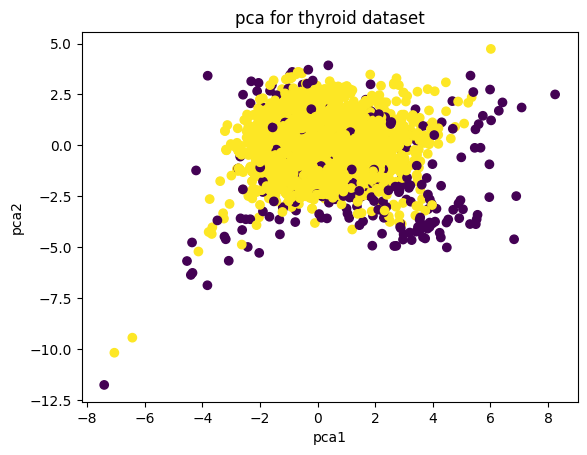

In [49]:
plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=labels
)
plt.xlabel("pca1")
plt.ylabel("pca2")
plt.title("pca for thyroid dataset")

In [50]:
import numpy as np

normal=np.sum(labels==1)
outlier=np.sum(labels==-1)

print("normal",normal)
print("outlier",outlier)

normal 6641
outlier 275


## LOF

In [51]:
from sklearn.neighbors import LocalOutlierFactor

neigh=LocalOutlierFactor()

In [55]:
labels=neigh.fit_predict(x_scaled)

Text(0.5, 1.0, 'pca for thyroid dataset')

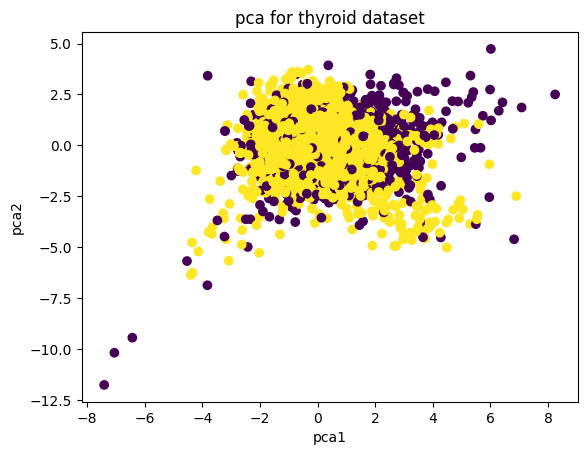

In [56]:
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=labels
)
plt.xlabel("pca1")
plt.ylabel("pca2")
plt.title("pca for thyroid dataset")

In [57]:
normal=np.sum(labels==1)
outlier=np.sum(labels==-1)

print("normal",normal)
print("outlier",outlier)

normal 6033
outlier 883
